<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [1]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [42]:
# loading the data: Wholesale customers data
data = pd.read_csv('Wholesale customers data.csv')

#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

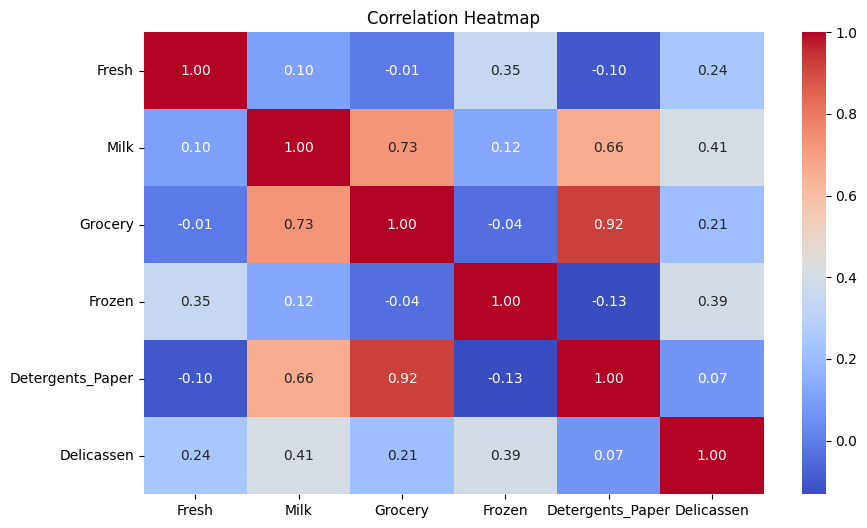

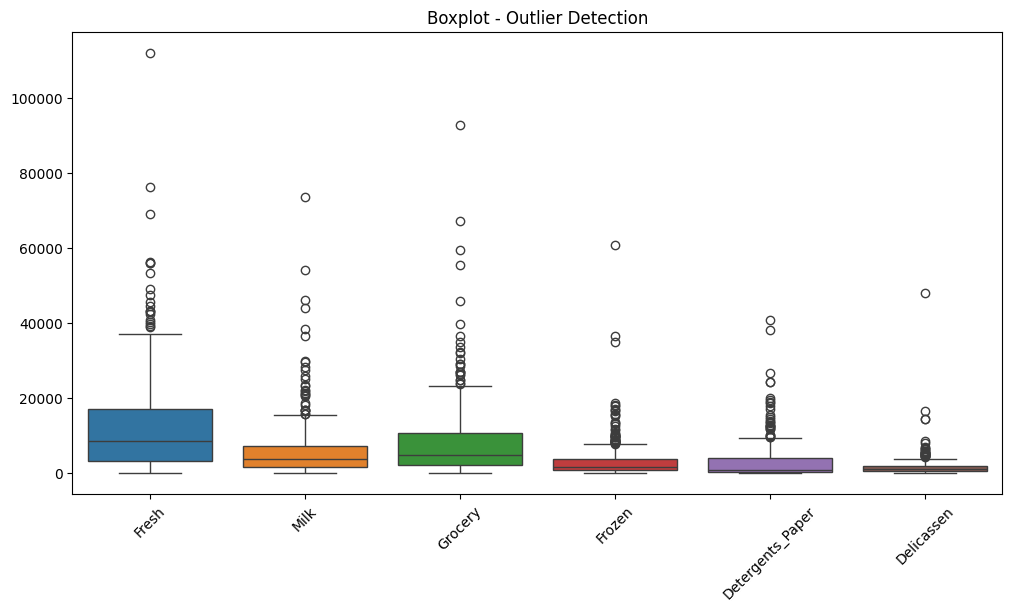

Fresh                2.561323
Milk                 4.053755
Grocery              3.587429
Frozen               5.907986
Detergents_Paper     3.631851
Delicassen          11.151586
dtype: float64

In [ ]:
# Your code here:
# 1) * What does each column mean?
data 
# Each column shows the annual spending of the consumer on diverse product categories.

# 2) * Any categorical data to convert?
# Channel and Region should be converted.
data = pd.get_dummies(data, columns=['Channel', 'Region'], drop_first=False)
# data # Check converted string into integer

# 3) Any missing data to remove?
data.isnull().sum() # No data to remove

# 4) Column collinearity - any high correlations?
# Using heatmap
drop_channel_region = data.drop(columns=['Channel_1', 'Channel_2', 'Region_1', 'Region_2', 'Region_3']) #drop, since they are categorical

plt.figure(figsize=(10, 6))
sns.heatmap(drop_channel_region.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
# Detergents_Papaer and Grocery are highly correlated (0.92). The rest are below 0.75

# 5) Descriptive statistics - any outliers to remove?
plt.figure(figsize=(12, 6))
sns.boxplot(data=drop_channel_region )
plt.title('Boxplot - Outlier Detection')
plt.xticks(rotation=45)
plt.show()
# Fresh and grocery has one extreme outlier respectively

# 6) * Column-wise data distribution - is the distribution skewed?
drop_channel_region.skew()
# Yes, all are skewed, especially Delicassen (extreme)



**Your observations here**

- ex.: Frozen, Grocery, Milk and Detergents Paper have a high...
- ...



# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [51]:
# Data cleaning and transformation are needed: Outliers and skewed values should be removed.

# Step 1: Removing outliers
Q1 = drop_channel_region.quantile(0.25)
Q3 = drop_channel_region.quantile(0.75)

IQR = Q3 - Q1
drop_channel_region_cleaned = drop_channel_region[~((drop_channel_region < (Q1 - 1.5 * IQR)) | (drop_channel_region > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Original shape: {drop_channel_region.shape}")
print(f"Cleaned shape: {drop_channel_region_cleaned.shape}")

# Step 2: Removing skewed values
drop_channel_region_log = np.log1p(drop_channel_region_cleaned)



Original shape: (440, 6)
Cleaned shape: (332, 6)


**Your comment here**

-  ...
-  ...

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [58]:
# Your import here:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
customers_scale = scaler.fit_transform(drop_channel_region_log)


# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [60]:
from sklearn.cluster import KMeans

kmeans = KMeans (n_clusters=3, random_state=0)
kmeans.fit(customers_scale)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### Looking to the elbow we can choose 2 like the correct number of clusters

In [65]:
kmeans_2 = KMeans(n_clusters=2).fit(customers_scale)

labels = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

In [67]:
drop_channel_region_cleaned['Label'] = clusters 

Count the values in `labels`.

In [70]:
# Your code here:
drop_channel_region_cleaned['Label'].value_counts()

Label
1    183
0    149
Name: count, dtype: int64

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [72]:
from sklearn.cluster import DBSCAN 

# Your code here
dbscan = DBSCAN(eps=0.5)
dbscan.fit(customers_scale)


drop_channel_region_cleaned['labels_DBSCAN'] = dbscan.labels_

drop_channel_region_cleaned[['Label', 'labels_DBSCAN']].head()

,Label,labels_DBSCAN
0,0,-1
1,0,-1
3,1,-1
5,0,-1
6,0,-1


Count the values in `labels_DBSCAN`.

In [73]:
# Your code here
drop_channel_region_cleaned['labels_DBSCAN'].value_counts()

labels_DBSCAN
-1    332
Name: count, dtype: int64

# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [74]:
def plot(x,y,hue):
    sns.scatterplot(x=x, 
                    y=y,
                    hue=hue)
    plt.title('Detergents Paper vs Milk ')
    return plt.show();

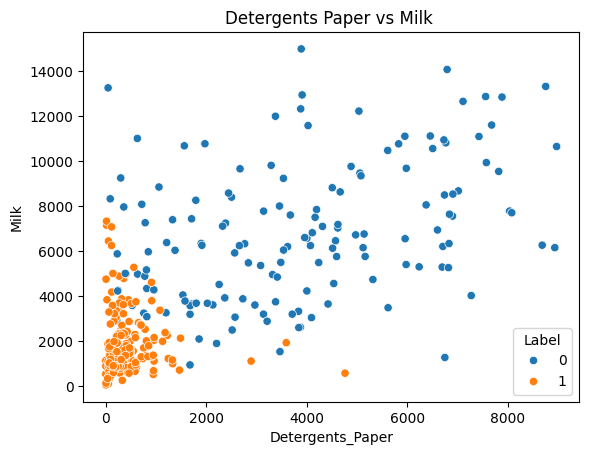

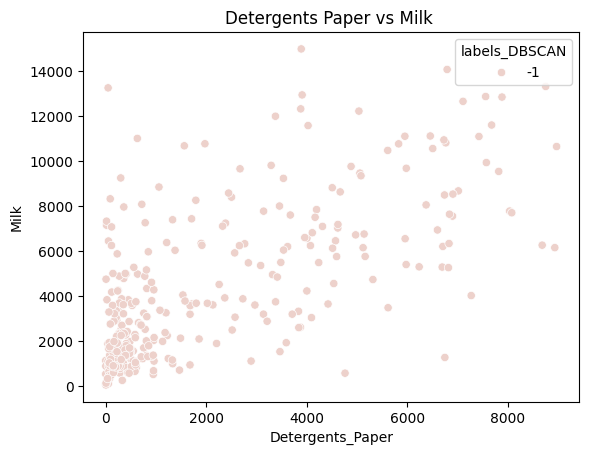

In [87]:
# K-Means labels
plot(drop_channel_region_cleaned['Detergents_Paper'], 
     drop_channel_region_cleaned['Milk'], 
     drop_channel_region_cleaned['Label'])

# DBSCAN labels
plot(drop_channel_region_cleaned['Detergents_Paper'], 
     drop_channel_region_cleaned['Milk'], 
     drop_channel_region_cleaned['labels_DBSCAN'])

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

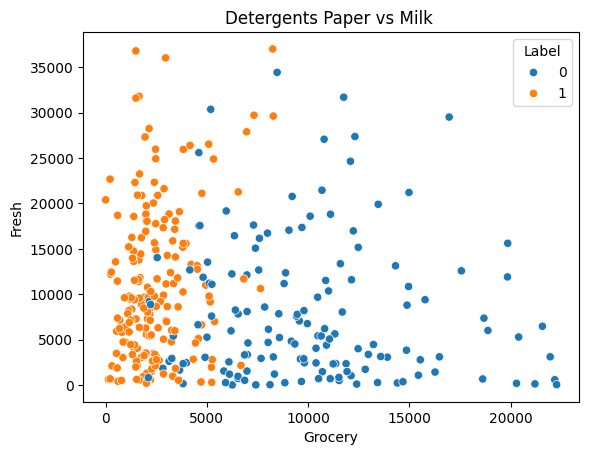

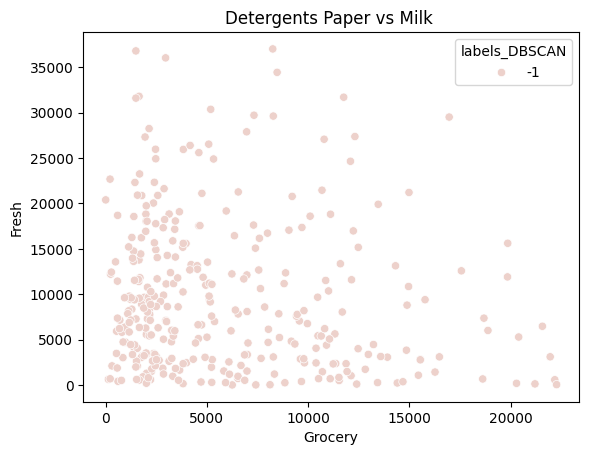

In [89]:
# Your code here:
# K-Means labels
plot(drop_channel_region_cleaned['Grocery'], 
     drop_channel_region_cleaned['Fresh'], 
     drop_channel_region_cleaned['Label'])

# DBSCAN labels
plot(drop_channel_region_cleaned['Grocery'], 
     drop_channel_region_cleaned['Fresh'], 
     drop_channel_region_cleaned['labels_DBSCAN'])

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

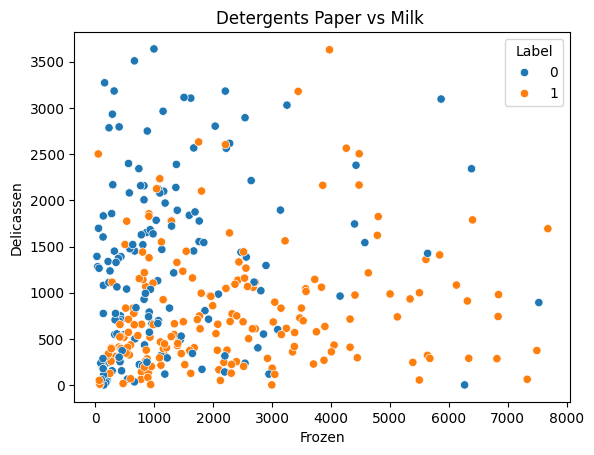

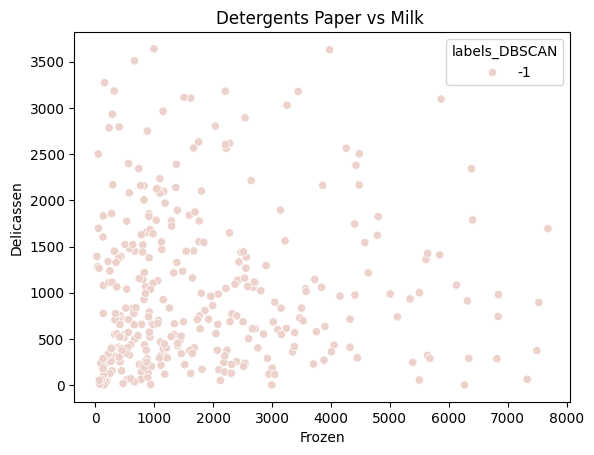

In [90]:
# Your code here:
# K-Means labels
plot(drop_channel_region_cleaned['Frozen'], 
     drop_channel_region_cleaned['Delicassen'], 
     drop_channel_region_cleaned['Label'])

# DBSCAN labels
plot(drop_channel_region_cleaned['Frozen'], 
     drop_channel_region_cleaned['Delicassen'], 
     drop_channel_region_cleaned['labels_DBSCAN'])


Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [92]:
# Your code here:
#K-Means
drop_channel_region_cleaned.groupby('Label').mean()



,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels_DBSCAN
Label,,,,,,,
0,7875.838926,6838.859060,10016.771812,1286.906040,3847.496644,1285.275168,-1.0
1,10908.393443,1879.398907,2503.852459,2332.147541,421.327869,797.846995,-1.0


In [93]:
#DBSCAN
drop_channel_region_cleaned.groupby('labels_DBSCAN').mean()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Label
labels_DBSCAN,,,,,,,
-1,9547.39759,4105.180723,5875.614458,1863.048193,1958.975904,1016.60241,0.551205


Which algorithm appears to perform better?

**Your observations here**

- KMeans performed better, as it could catogorized into 2 clusters, whereas DBSCAN only managed to cluster 1 group.


# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

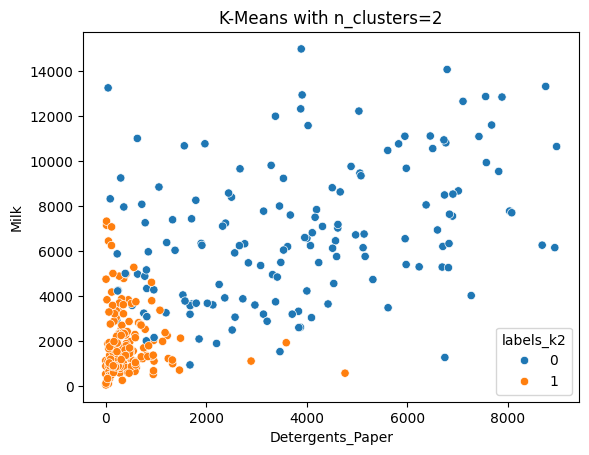

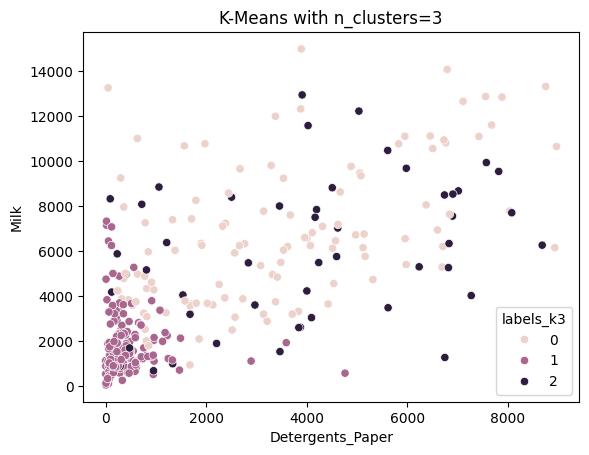

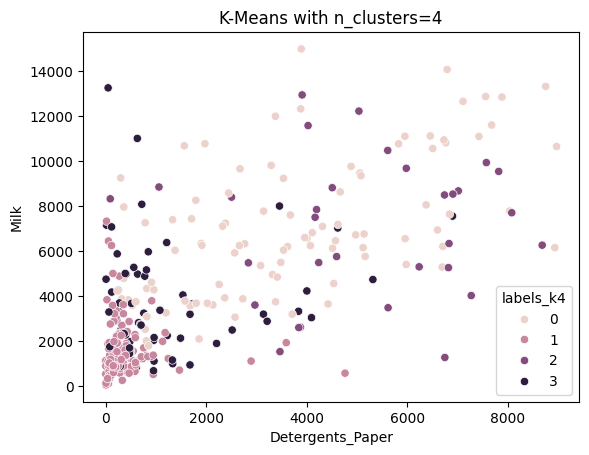

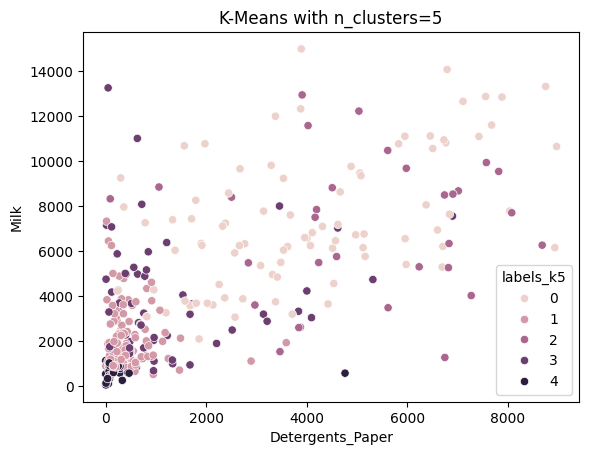

In [96]:
# Your code here:

# Try different numbers of clusters
for n in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=n, random_state=42)
    drop_channel_region_cleaned[f'labels_k{n}'] = kmeans.fit_predict(customers_scale)
    
    sns.scatterplot(x=drop_channel_region_cleaned['Detergents_Paper'], 
                    y=drop_channel_region_cleaned['Milk'], 
                    hue=drop_channel_region_cleaned[f'labels_k{n}'])
    plt.title(f'K-Means with n_clusters={n}')
    plt.show()

**Your comment here**

- 2 clusters is the most optimum

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

eps=0.5, min_samples=5 → Clusters: 0, Noise points: 332


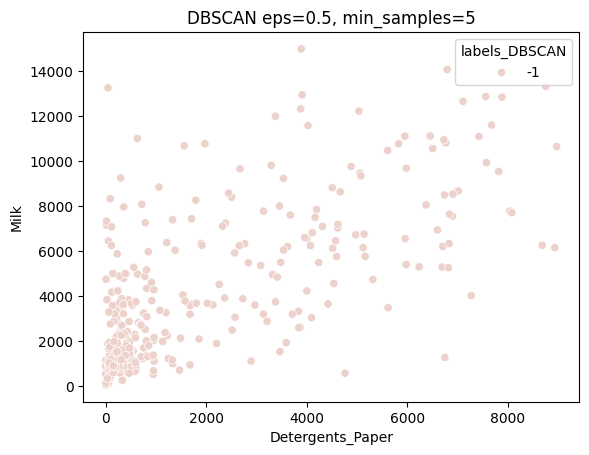

eps=1.0, min_samples=5 → Clusters: 3, Noise points: 102


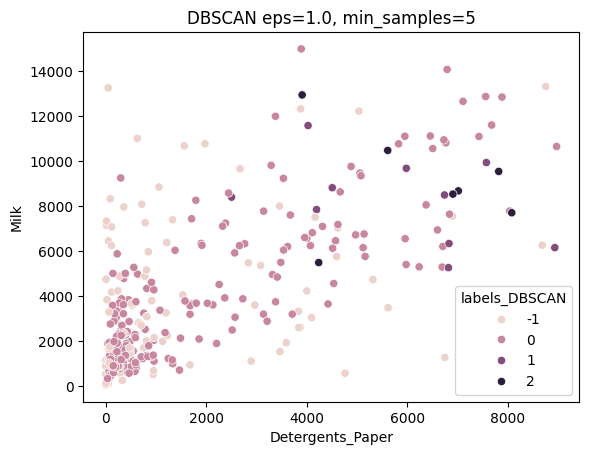

eps=2.0, min_samples=5 → Clusters: 1, Noise points: 16


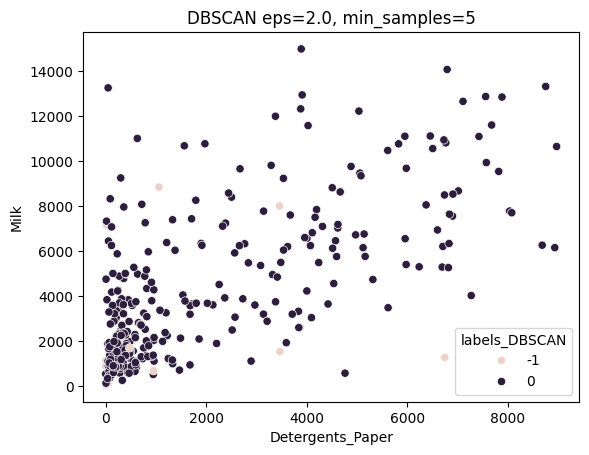

eps=2.0, min_samples=10 → Clusters: 1, Noise points: 18


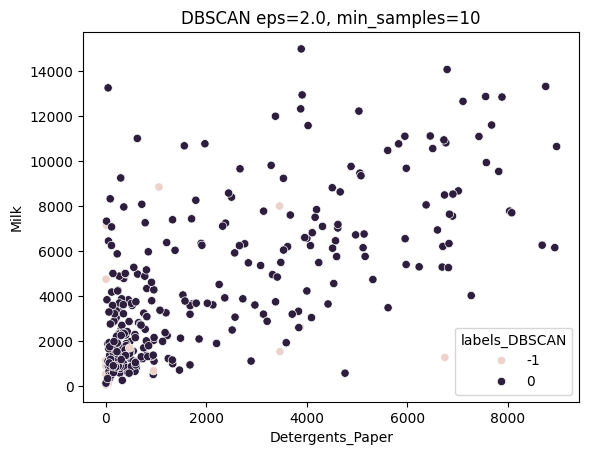

eps=3.0, min_samples=5 → Clusters: 1, Noise points: 3


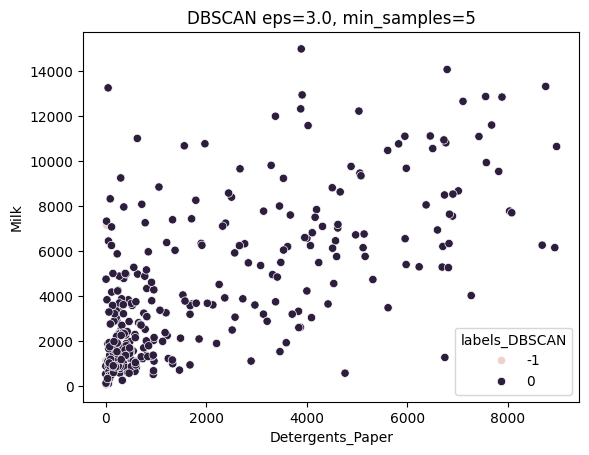

In [97]:
# Your code here
params = [
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 5},
    {'eps': 2.0, 'min_samples': 5},
    {'eps': 2.0, 'min_samples': 10},
    {'eps': 3.0, 'min_samples': 5},
]

for p in params:
    dbscan = DBSCAN(eps=p['eps'], min_samples=p['min_samples'])
    labels = dbscan.fit_predict(customers_scale)
    
    drop_channel_region_cleaned['labels_DBSCAN'] = labels
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"eps={p['eps']}, min_samples={p['min_samples']} → Clusters: {n_clusters}, Noise points: {n_noise}")
    
    sns.scatterplot(x=drop_channel_region_cleaned['Detergents_Paper'],
                    y=drop_channel_region_cleaned['Milk'],
                    hue=drop_channel_region_cleaned['labels_DBSCAN'])
    plt.title(f"DBSCAN eps={p['eps']}, min_samples={p['min_samples']}")
    plt.show()

eps=0.8, min_samples=3 → Clusters: 7, Noise points: 167


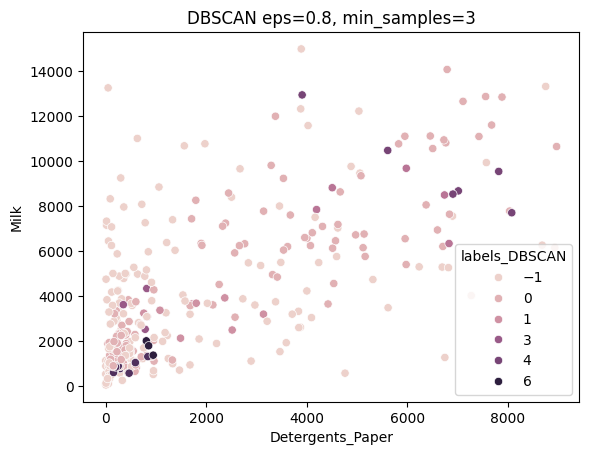

eps=1.0, min_samples=3 → Clusters: 3, Noise points: 87


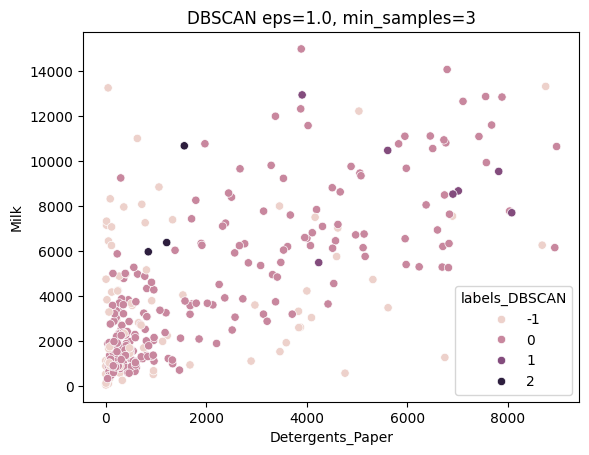

eps=1.0, min_samples=5 → Clusters: 3, Noise points: 102


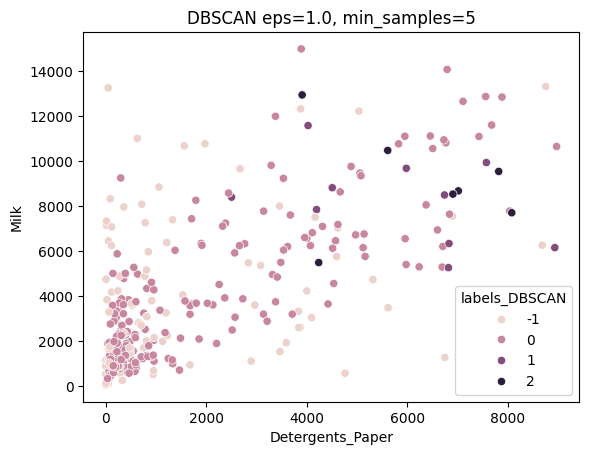

eps=1.0, min_samples=8 → Clusters: 2, Noise points: 137


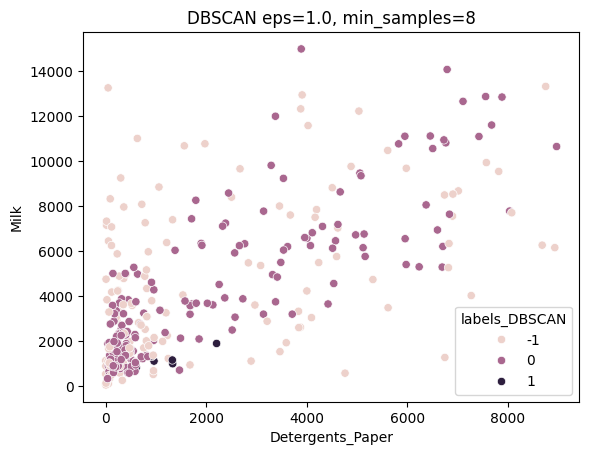

eps=1.2, min_samples=5 → Clusters: 1, Noise points: 57


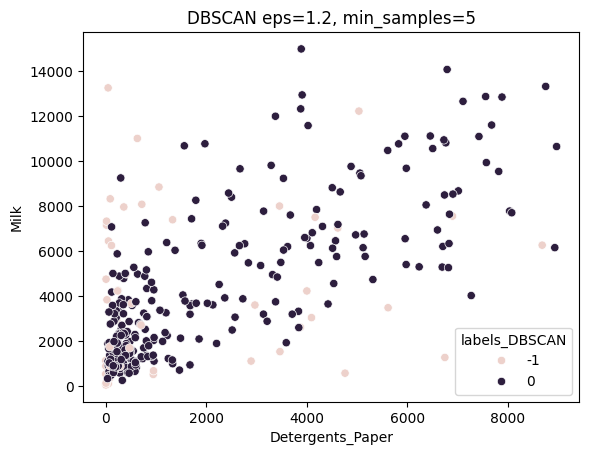

eps=1.5, min_samples=5 → Clusters: 1, Noise points: 34


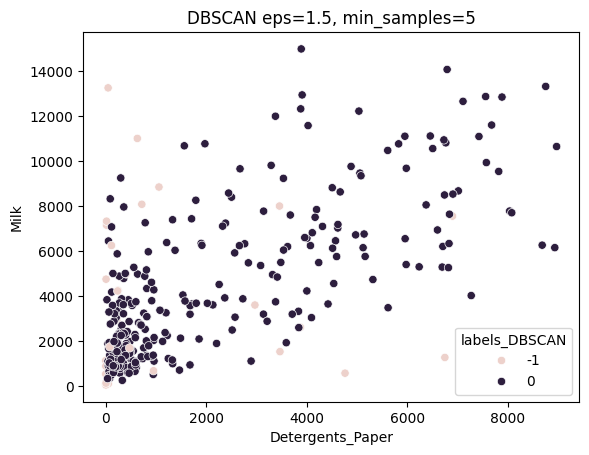

In [98]:
# Your code here
params = [
    {'eps': 0.8, 'min_samples': 3},
    {'eps': 1.0, 'min_samples': 3},
    {'eps': 1.0, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 8},
    {'eps': 1.2, 'min_samples': 5},
    {'eps': 1.5, 'min_samples': 5}
]

for p in params:
    dbscan = DBSCAN(eps=p['eps'], min_samples=p['min_samples'])
    labels = dbscan.fit_predict(customers_scale)
    
    drop_channel_region_cleaned['labels_DBSCAN'] = labels
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"eps={p['eps']}, min_samples={p['min_samples']} → Clusters: {n_clusters}, Noise points: {n_noise}")
    
    sns.scatterplot(x=drop_channel_region_cleaned['Detergents_Paper'],
                    y=drop_channel_region_cleaned['Milk'],
                    hue=drop_channel_region_cleaned['labels_DBSCAN'])
    plt.title(f"DBSCAN eps={p['eps']}, min_samples={p['min_samples']}")
    plt.show()

**Your comment here**

- best is eps=1.0, min_samples=5 because, it formed 3 meaningful clusters, min_samples is the standard default for DBSCAN (statiscally more reliable), Clusters show visible separation on the scatter plot.
- Nevertheless, KMeans is more reliabe=le